In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import LambdaLR
import timm
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import math

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

c:\Users\Animesh Gupta\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
# CIFAR-10 images are 32x32, we keep them small for the custom ViT
img_size = 32
patch_size = 4   # 32/4 = 8x8 = 64 patches

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),   # strong augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full datasets
full_train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

In [4]:
targets = np.array(full_train_set.targets)
classes = np.unique(targets)

train_indices = []
val_indices = []
samples_per_class = 100

for cls in classes:
    cls_idx = np.where(targets == cls)[0]
    np.random.shuffle(cls_idx)
    selected = cls_idx[:samples_per_class + samples_per_class]
    n_val = samples_per_class
    val_indices.extend(selected[:samples_per_class])
    train_indices.extend(selected[samples_per_class:])

train_subset = Subset(full_train_set, train_indices)
val_subset = Subset(full_train_set, val_indices)

train_subset.dataset.transform = train_transform
val_subset.dataset.transform = eval_transform

print(f'Train samples: {len(train_subset)}, Val samples: {len(val_subset)}')

Train samples: 1000, Val samples: 1000


In [9]:
batch_size = 64   # small batch size appropriate for tiny dataset
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=1)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=1)

In [10]:
model = timm.models.vision_transformer.VisionTransformer(
    img_size=32,
    patch_size=8,
    embed_dim=384,
    depth=4,
    num_heads=4,
    mlp_ratio=4,
    num_classes=10,
    in_chans=3
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params / 1e6:.2f}M')   # should be around 2-3M

Total parameters: 7.18M


In [11]:
criterion = SoftTargetCrossEntropy()
mixup_fn = Mixup(mixup_alpha=0.8, cutmix_alpha=1.0, prob=0.5, num_classes=10)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

# Training length: 100 epochs (from-scratch needs more time)
total_epochs = 200
warmup_epochs = 5

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(warmup_epochs)
    else:
        progress = float(epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

In [12]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(total_epochs):
    # ---------- Train ----------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{total_epochs} [Train]')
    for images, labels in loop:
        images, labels_orig = images.to(device), labels.to(device)
        images, labels_mixed = mixup_fn(images, labels_orig)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_mixed)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_orig).sum().item()
        total += labels_orig.size(0)
        loop.set_postfix(loss=loss.item(), acc=correct/total)
    
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # ---------- Validation ----------
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{total_epochs} [Val]'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)   # hard loss for val
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_val_loss = running_loss / total
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    print(f'Epoch {epoch+1}: Train Loss={epoch_train_loss:.4f}, Train Acc={epoch_train_acc:.4f} | Val Loss={epoch_val_loss:.4f}, Val Acc={epoch_val_acc:.4f}')
    
    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_vanilla_vit_cifar10.pth')
        print(f' Best model saved (Val Acc: {best_val_acc:.4f})')
    
    scheduler.step()

Epoch 1/200 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.23it/s]


Epoch 1: Train Loss=2.2134, Train Acc=0.2090 | Val Loss=2.0398, Val Acc=0.2360
 Best model saved (Val Acc: 0.2360)


Epoch 2/200 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.41it/s]


Epoch 2: Train Loss=2.1062, Train Acc=0.2520 | Val Loss=2.0134, Val Acc=0.2690
 Best model saved (Val Acc: 0.2690)


Epoch 3/200 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.28it/s]


...

Epoch 198: Train Loss=1.1257, Train Acc=0.7500 | Val Loss=1.8468, Val Acc=0.3710


Epoch 199/200 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.37it/s]


Epoch 199: Train Loss=0.5871, Train Acc=1.0000 | Val Loss=1.8468, Val Acc=0.3710


Epoch 200/200 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.40it/s]

Epoch 200: Train Loss=1.0455, Train Acc=0.7490 | Val Loss=1.8468, Val Acc=0.3710


In [13]:
# Load best checkpoint
model.load_state_dict(torch.load('best_vanilla_vit_cifar10.pth'))
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f'Final Test Accuracy (full test set): {test_acc:.4f} ({test_acc*100:.2f}%)')

Testing: 100%|██████████| 157/157 [00:05<00:00, 28.90it/s]

Final Test Accuracy (full test set): 0.3622 (36.22%)


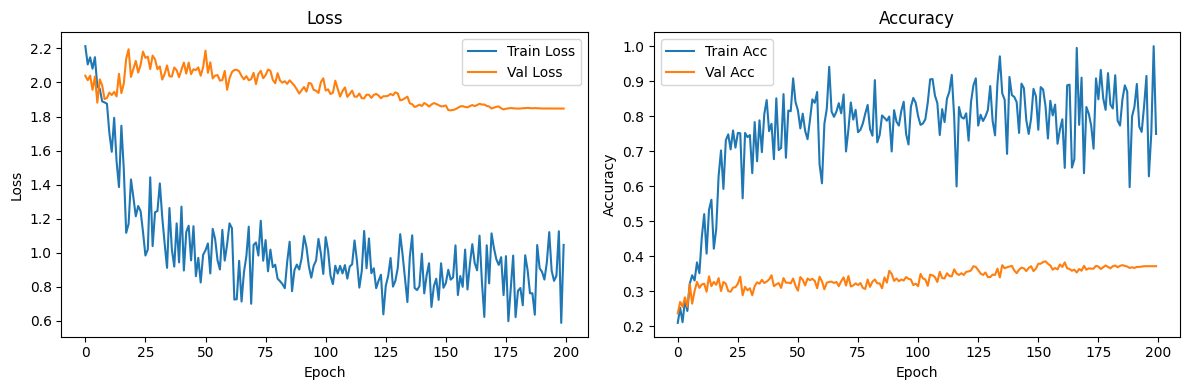

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()